# Trực Quan Hóa Sự Thay Đổi Phân Bố Dữ Liệu Trước và Sau Xử Lý

## Mục đích
So sánh phân bố dữ liệu **trước xử lý** (raw1.csv) và **sau xử lý** (clean1.csv) để visualize sự ảnh hưởng của các bước normalization và cleaning.

## Các cột được phân tích (8 cột):
1. **price** - Giá sản phẩm
2. **discount_percent** - Chiết khấu (%)
3. **product_rating** - Đánh giá sản phẩm
4. **number_of_reviews** - Số lượng đánh giá
5. **freeship** - Miễn phí vận chuyển (0/1)
6. **sold** - Số lượng đã bán
7. **category** - Danh mục sản phẩm
8. **Thêm một cột để phân tích khác** (tùy chọn)

---

## 1. Import Thư Viện

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

print("✓ Thư viện đã được import thành công")

✓ Thư viện đã được import thành công


## 2. Load và Explore Dữ Liệu

In [33]:
print("📂 Load dữ liệu từ raw1.csv (TRƯỚC xử lý)...")
df_before = pd.read_csv('raw1.csv', encoding='utf-8-sig')
print(f"✓ Đã load {len(df_before)} dòng, {len(df_before.columns)} cột")
print(f"Columns: {list(df_before.columns)}\n")

print("📊 Thông tin dữ liệu trước xử lý:")
print(f"Shape: {df_before.shape}")
print(f"Memory usage: {df_before.memory_usage(deep=True).sum() / 1024:.2f} KB\n")
print(df_before.head())
print(f"\nData types:\n{df_before.dtypes}\n")
print("=" * 80)

📂 Load dữ liệu từ raw1.csv (TRƯỚC xử lý)...
✓ Đã load 1565 dòng, 8 cột
Columns: ['product_name', 'price', 'discount_percent', 'product_rating', 'number_of_reviews', 'freeship', 'category', 'sold']

📊 Thông tin dữ liệu trước xử lý:
Shape: (1565, 8)
Memory usage: 879.89 KB

                                        product_name      price  \
0  Điện Thoại Samsung Galaxy A56 5G - Hàng Chính ...  7.490.000   
1  Điện thoại Samsung Galaxy A06 5G (4/128GB), Mà...  2.450.000   
2  Điện thoại Tecno SPARK GO 2 ( 4GB - 64GB) - Hà...  1.990.000   
3  Điện thoại Xiaomi Redmi 15 8GB/128GB - Hàng Ch...  3.990.000   
4  Điện thoại Samsung Galaxy A26 5G (8/128GB), Mặ...  4.990.000   

  discount_percent  product_rating number_of_reviews  freeship    category  \
0             -24%             5.0              (19)       1.0  điện thoại   
1             -38%             4.7              (16)       1.0  điện thoại   
2             -33%             5.0               (1)       1.0  điện thoại   
3           

In [34]:
import os

print("\n📂 Load dữ liệu từ clean1.csv (SAU xử lý)...")
if os.path.exists('clean1.csv'):
    df_after = pd.read_csv('clean1.csv', encoding='utf-8-sig')
    print(f"✓ Đã load {len(df_after)} dòng, {len(df_after.columns)} cột")
else:
    print("⚠️ File clean1.csv chưa tồn tại. Thực hiện xử lý dữ liệu...")
    
    def remove_vietnamese_diacritics(text):
        if pd.isna(text):
            return text
        text = str(text)
        nfkd_form = unicodedata.normalize('NFKD', text)
        return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])
    
    df_after = df_before.copy()
    
    def extract_sold(x):
        if pd.isna(x) or x == '' or x == 'N/A':
            return 0
        match = re.findall(r'\d+', str(x))
        return int(match[-1]) if match else 0
    
    def extract_price(x):
        if pd.isna(x) or x == '':
            return 0
        text = str(x).replace('.', '').strip()
        match = re.findall(r'\d+', text)
        return int(''.join(match)) if match else 0
    
    def extract_discount(x):
        if pd.isna(x) or x == '' or x == 'N/A':
            return 0
        text = str(x).replace('%', '').replace('-', '').strip()
        match = re.findall(r'\d+', text)
        return int(match[0]) if match else 0
    
    def clean_product_name(x):
        if pd.isna(x):
            return ""
        text = str(x).lower()
        text = remove_vietnamese_diacritics(text)
        text = re.sub(r'\s*-\s*hang\s+chinh\s+hang\s*$', '', text)
        text = re.sub(r'[^\w\s\-\(\)]+', '', text)
        return ' '.join(text.split())
    
    def normalize_freeship(x):
        if pd.isna(x) or x == '' or x == 'N/A':
            return 0
        return 1 if str(x).lower().strip() in ['1', '1.0', 'true', 'yes', 'co'] else 0
    
    def clean_category(x):
        if pd.isna(x) or x == '':
            return 'other'
        text = str(x).lower()
        text = remove_vietnamese_diacritics(text)
        text = re.sub(r'[^\w\s]+', '', text)
        text = ' '.join(text.split())
        return text if text else 'other'
    
    def extract_reviews(x):
        if pd.isna(x) or x == '' or x == 'N/A':
            return np.nan
        text = str(x).strip('()')
        match = re.findall(r'\d+', text)
        return int(match[0]) if match else np.nan
    
    df_after['sold'] = df_after['sold'].apply(extract_sold)
    df_after['price'] = df_after['price'].apply(extract_price)
    df_after['discount_percent'] = df_after['discount_percent'].apply(extract_discount)
    df_after['product_name'] = df_after['product_name'].apply(clean_product_name)
    df_after['freeship'] = df_after['freeship'].apply(normalize_freeship)
    df_after['category'] = df_after['category'].apply(clean_category)
    df_after['number_of_reviews'] = df_after['number_of_reviews'].apply(extract_reviews)
    
    df_after['product_rating'] = pd.to_numeric(df_after['product_rating'], errors='coerce')
    median_rating = df_after['product_rating'].median()
    df_after['product_rating'] = df_after['product_rating'].fillna(median_rating)
    
    median_reviews = df_after['number_of_reviews'].median()
    df_after['number_of_reviews'] = df_after['number_of_reviews'].fillna(median_reviews)
    
    df_after = df_after[df_after['price'] > 0]
    df_after = df_after[df_after['sold'] >= 0]
    
    initial_rows = len(df_after)
    df_after = df_after.drop_duplicates(subset=['product_name', 'price', 'category'], keep='first')
    
    df_after['price'] = df_after['price'].astype('int64')
    df_after['discount_percent'] = df_after['discount_percent'].astype('int64')
    df_after['product_rating'] = df_after['product_rating'].astype('float64')
    df_after['number_of_reviews'] = df_after['number_of_reviews'].astype('int64')
    df_after['freeship'] = df_after['freeship'].astype('int64')
    df_after['sold'] = df_after['sold'].astype('int64')
    
    print(f"✓ Xử lý xong. {len(df_after)} dòng tham gia trực quan hóa")

print(f"\n📊 Thông tin dữ liệu sau xử lý:")
print(f"Shape: {df_after.shape}")
print(df_after.head())
print("\n" + "=" * 80)


📂 Load dữ liệu từ clean1.csv (SAU xử lý)...
✓ Đã load 1272 dòng, 8 cột

📊 Thông tin dữ liệu sau xử lý:
Shape: (1272, 8)
                                        product_name    price  \
0                   đien thoai samsung galaxy a56 5g  7490000   
1  đien thoai samsung galaxy a06 5g (4128gb) man ...  2450000   
2          đien thoai tecno spark go 2 ( 4gb - 64gb)  1990000   
3                đien thoai xiaomi redmi 15 8gb128gb  3990000   
4  đien thoai samsung galaxy a26 5g (8128gb) mat ...  4990000   

   discount_percent  product_rating  number_of_reviews  freeship    category  \
0                24             5.0                 19         1  đien thoai   
1                38             4.7                 16         1  đien thoai   
2                33             5.0                  1         1  đien thoai   
3                23             5.0                 10         1  đien thoai   
4                29             5.0                 24         1  đien thoai   

    sol

## 3. So Sánh Phân Bố Dữ Liệu - PRICE (Giá Sản Phẩm)

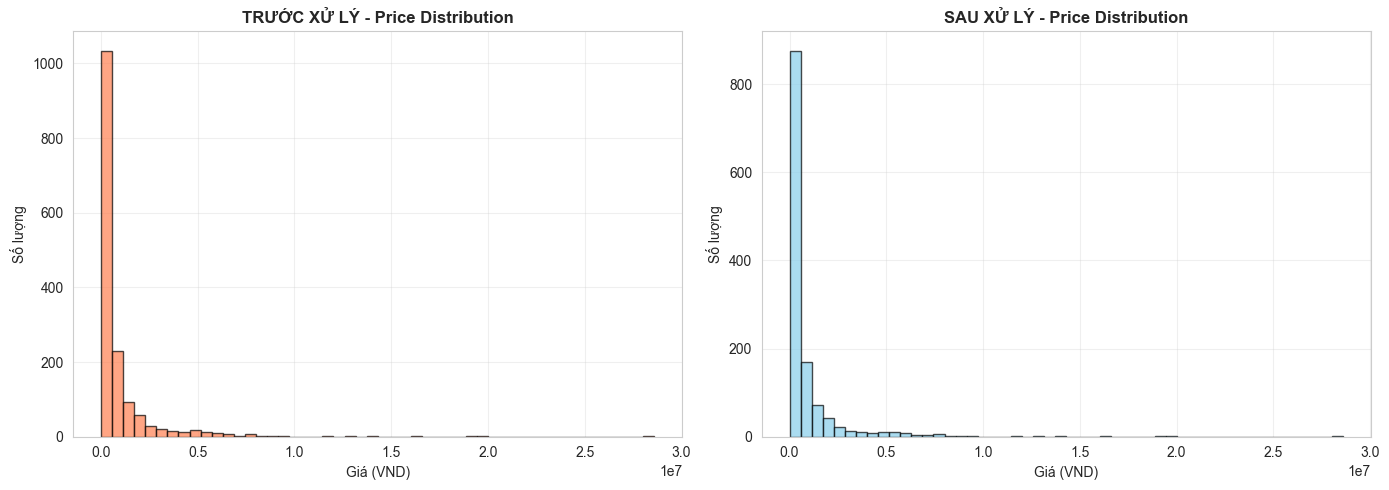


📊 Thống kê PRICE:
TRƯỚC: Mean=922365 | Median=319000 | Std=1941436
SAU:   Mean=879687 | Median=287000 | Std=1969287


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_before = pd.to_numeric(df_before['price'].astype(str).str.replace('.', ''), errors='coerce').dropna()
price_after = df_after['price']

axes[0].hist(price_before, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0].set_title('TRƯỚC XỬ LÝ - Price Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá (VND)')
axes[0].set_ylabel('Số lượng')
axes[0].grid(alpha=0.3)

axes[1].hist(price_after, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[1].set_title('SAU XỬ LÝ - Price Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá (VND)')
axes[1].set_ylabel('Số lượng')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Thống kê PRICE:")
print(f"TRƯỚC: Mean={price_before.mean():.0f} | Median={price_before.median():.0f} | Std={price_before.std():.0f}")
print(f"SAU:   Mean={price_after.mean():.0f} | Median={price_after.median():.0f} | Std={price_after.std():.0f}")

Sau xử lý (clean và normalization) ta thấy cột giá thấp hơn , thì những thay đổi đổi trong cột giá này do việc xóa các dòng trùng lặp


## 4. So Sánh Phân Bố Dữ Liệu - DISCOUNT_PERCENT (Chiết Khấu)

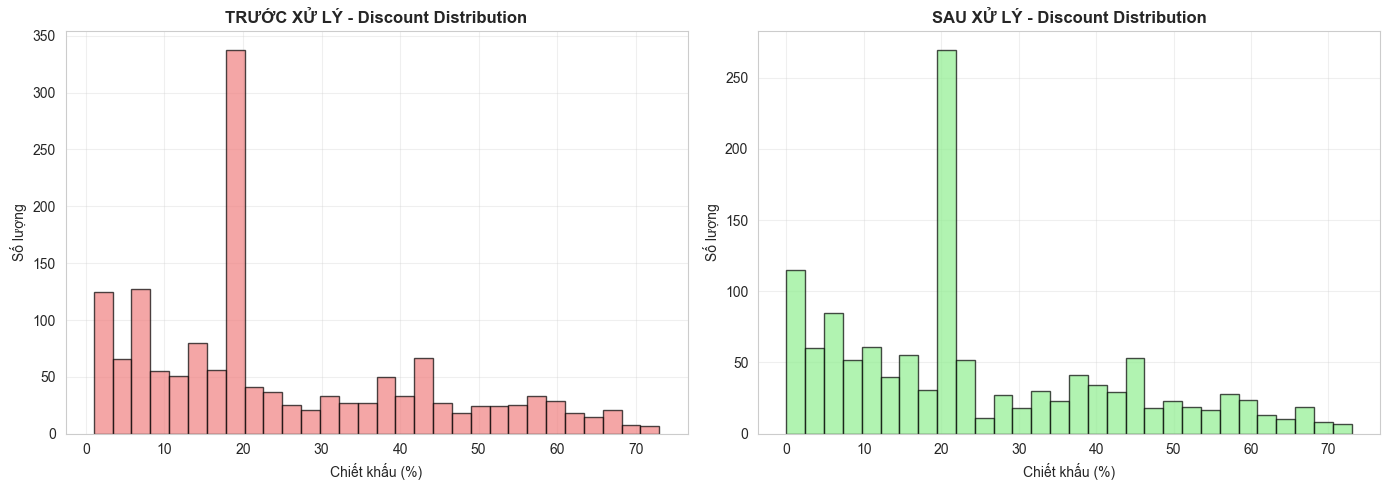


📊 Thống kê DISCOUNT_PERCENT:
TRƯỚC: Mean=24.8% | Median=20.0% | Std=18.0%
SAU:   Mean=24.5% | Median=20.0% | Std=18.3%


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

discount_before = pd.to_numeric(df_before['discount_percent'].astype(str).str.replace('%', '').str.replace('-', ''), errors='coerce').dropna()
discount_after = df_after['discount_percent']

axes[0].hist(discount_before, bins=30, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0].set_title('TRƯỚC XỬ LÝ - Discount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Chiết khấu (%)')
axes[0].set_ylabel('Số lượng')
axes[0].grid(alpha=0.3)

axes[1].hist(discount_after, bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1].set_title('SAU XỬ LÝ - Discount Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Chiết khấu (%)')
axes[1].set_ylabel('Số lượng')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Thống kê DISCOUNT_PERCENT:")
print(f"TRƯỚC: Mean={discount_before.mean():.1f}% | Median={discount_before.median():.1f}% | Std={discount_before.std():.1f}%")
print(f"SAU:   Mean={discount_after.mean():.1f}% | Median={discount_after.median():.1f}% | Std={discount_after.std():.1f}%")

## 5. So Sánh Phân Bố Dữ Liệu - PRODUCT_RATING (Đánh Giá Sản Phẩm)

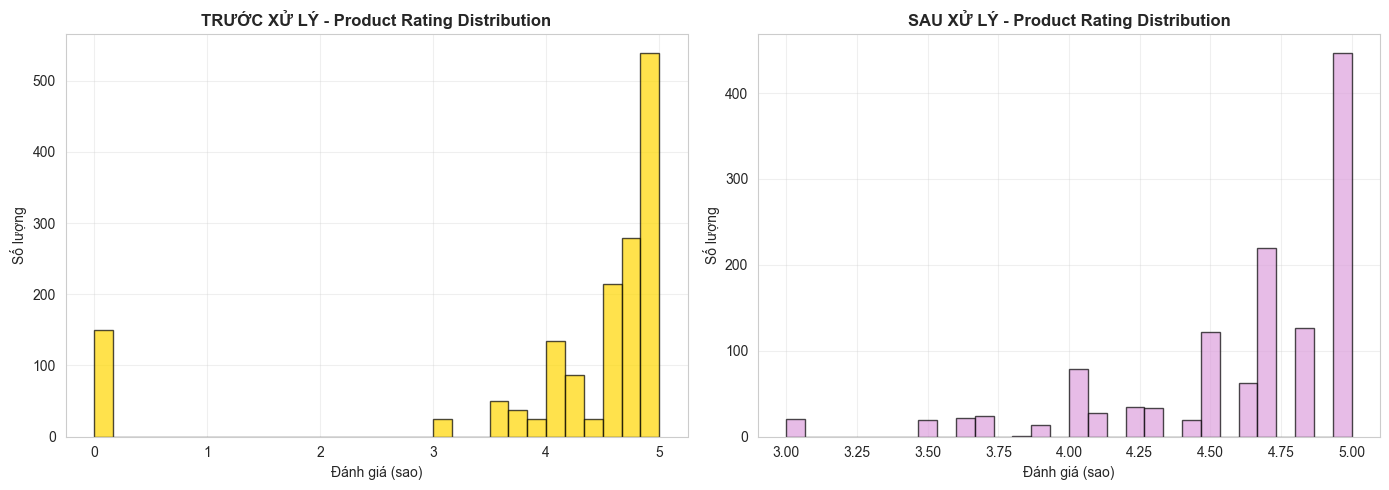


📊 Thống kê PRODUCT_RATING:
TRƯỚC: Mean=4.15⭐ | Median=4.70⭐ | Std=1.42
SAU:   Mean=4.61⭐ | Median=4.70⭐ | Std=0.44


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def normalize_rating(x):
    if pd.isna(x) or x == '' or x == 'N/A':
        return 0
    return float(x)

rating_before = df_before['product_rating'].apply(normalize_rating)
rating_after = df_after['product_rating']

axes[0].hist(rating_before, bins=30, color='gold', alpha=0.7, edgecolor='black')
axes[0].set_title('TRƯỚC XỬ LÝ - Product Rating Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Đánh giá (sao)')
axes[0].set_ylabel('Số lượng')
axes[0].grid(alpha=0.3)

axes[1].hist(rating_after, bins=30, color='plum', alpha=0.7, edgecolor='black')
axes[1].set_title('SAU XỬ LÝ - Product Rating Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Đánh giá (sao)')
axes[1].set_ylabel('Số lượng')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Thống kê PRODUCT_RATING:")
print(f"TRƯỚC: Mean={rating_before.mean():.2f}⭐ | Median={rating_before.median():.2f}⭐ | Std={rating_before.std():.2f}")
print(f"SAU:   Mean={rating_after.mean():.2f}⭐ | Median={rating_after.median():.2f}⭐ | Std={rating_after.std():.2f}")

- Ở đây ta thấy dữ liệu về ở mức 0 sao thuộc file raw thường do nó thuộc các sản phẩm mới chưa có đánh giá 
- Mức 1 sao -> 3 sao thì hầu hết các sản phẩm này ở trên sàn bị sàn loại bỏ hoặc do người bán gỡ sản phẩm nên hầu hết không có

## 6. So Sánh Phân Bố Dữ Liệu - NUMBER_OF_REVIEWS (Số Đánh Giá)

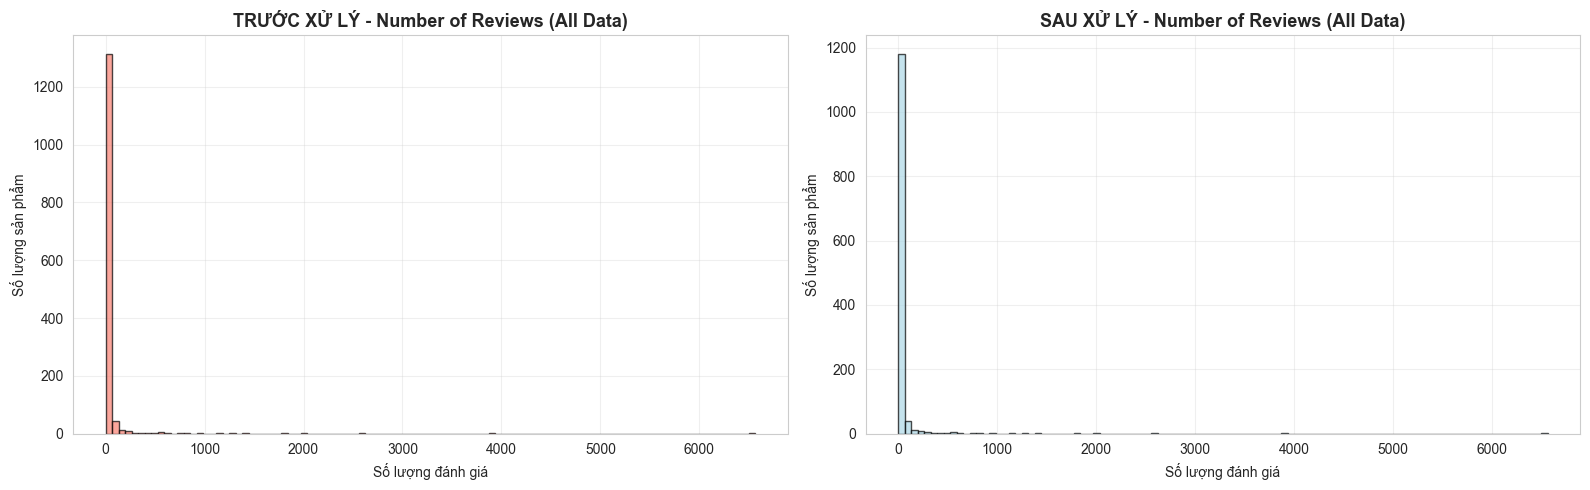

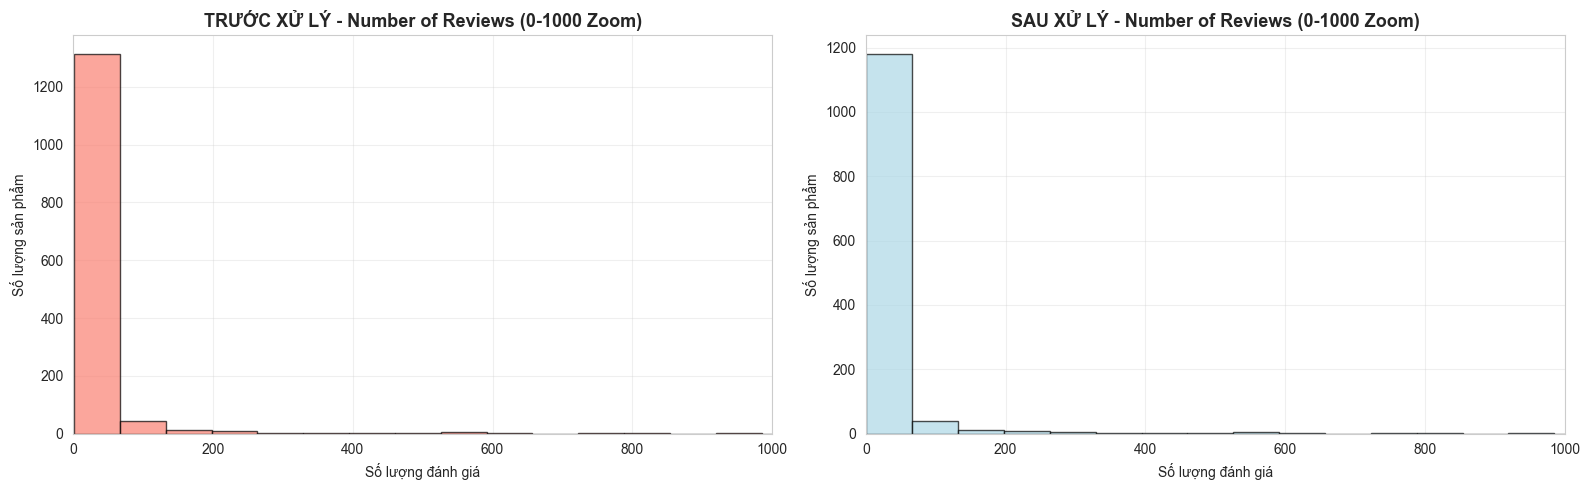


📊 Thống kê NUMBER_OF_REVIEWS:
TRƯỚC: Mean=42 | Median=3 | Std=264
SAU:   Mean=44 | Median=3 | Std=277


In [38]:
def extract_reviews_temp(x):
    if pd.isna(x) or x == '' or x == 'N/A':
        return np.nan
    text = str(x).strip('()')
    match = re.findall(r'\d+', text)
    return int(match[0]) if match else np.nan

reviews_before = df_before['number_of_reviews'].apply(extract_reviews_temp).dropna()
reviews_after = df_after['number_of_reviews']

# Hình 1: Toàn bộ dữ liệu
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))

axes1[0].hist(reviews_before, bins=100, color='salmon', alpha=0.7, edgecolor='black')
axes1[0].set_title('TRƯỚC XỬ LÝ - Number of Reviews (All Data)', fontsize=13, fontweight='bold')
axes1[0].set_xlabel('Số lượng đánh giá')
axes1[0].set_ylabel('Số lượng sản phẩm')
axes1[0].grid(alpha=0.3)

axes1[1].hist(reviews_after, bins=100, color='lightblue', alpha=0.7, edgecolor='black')
axes1[1].set_title('SAU XỬ LÝ - Number of Reviews (All Data)', fontsize=13, fontweight='bold')
axes1[1].set_xlabel('Số lượng đánh giá')
axes1[1].set_ylabel('Số lượng sản phẩm')
axes1[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Hình 2: Zoom vào 0-1000
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

axes2[0].hist(reviews_before, bins=100, color='salmon', alpha=0.7, edgecolor='black')
axes2[0].set_xlim(0, 1000)
axes2[0].set_title('TRƯỚC XỬ LÝ - Number of Reviews (0-1000 Zoom)', fontsize=13, fontweight='bold')
axes2[0].set_xlabel('Số lượng đánh giá')
axes2[0].set_ylabel('Số lượng sản phẩm')
axes2[0].grid(alpha=0.3)

axes2[1].hist(reviews_after, bins=100, color='lightblue', alpha=0.7, edgecolor='black')
axes2[1].set_xlim(0, 1000)
axes2[1].set_title('SAU XỬ LÝ - Number of Reviews (0-1000 Zoom)', fontsize=13, fontweight='bold')
axes2[1].set_xlabel('Số lượng đánh giá')
axes2[1].set_ylabel('Số lượng sản phẩm')
axes2[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Thống kê NUMBER_OF_REVIEWS:")
print(f"TRƯỚC: Mean={reviews_before.mean():.0f} | Median={reviews_before.median():.0f} | Std={reviews_before.std():.0f}")
print(f"SAU:   Mean={reviews_after.mean():.0f} | Median={reviews_after.median():.0f} | Std={reviews_after.std():.0f}")

- Ở đây ta thấy độ lệch chuẩn (standard deviation) cao , do có 1 số sản phẩm có số lượt đánh giá vượt trội ở múc 4000 , 6000 cách xa mức tiêu chuẩn bình thường của các sản phẩm khác (0-200)

## 7. So Sánh Phân Bố Dữ Liệu - FREESHIP (Miễn Phí Vận Chuyển)

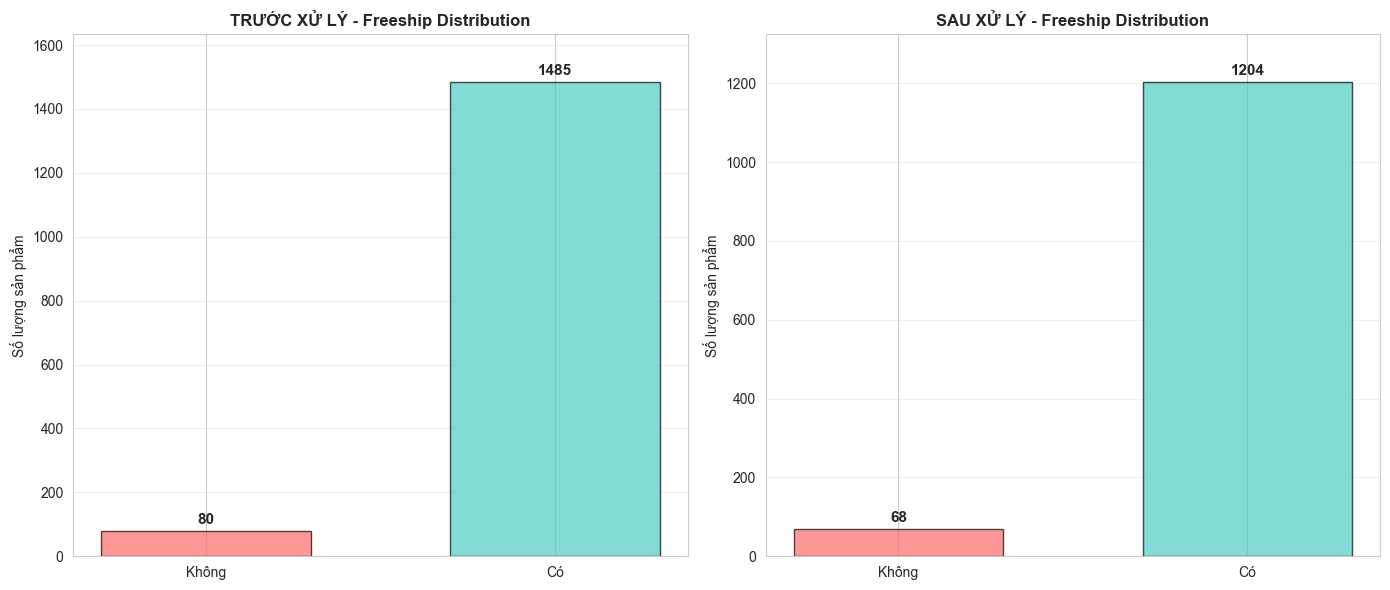


📊 Thống kê FREESHIP:
TRƯỚC: Không=80 | Có=1485
SAU:   Không=68 | Có=1204


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def normalize_freeship_temp(x):
    if pd.isna(x) or x == '' or x == 'nan':
        return 0
    try:
        # Xử lý nếu là số (1.0, 1, 0, v.v.)
        val = float(x)
        return 1 if val > 0 else 0
    except (ValueError, TypeError):
        # Xử lý nếu là text
        val = str(x).lower().strip()
        return 1 if val in ['1', 'true', 'yes', 'co', 'có'] else 0

freeship_before = df_before['freeship'].apply(normalize_freeship_temp)
freeship_after = df_after['freeship']

freeship_before_counts = freeship_before.value_counts()
freeship_after_counts = freeship_after.value_counts()

# Trước xử lý
values_before = [freeship_before_counts.get(0, 0), freeship_before_counts.get(1, 0)]
bars1 = axes[0].bar(['Không', 'Có'], values_before, color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black', width=0.6)
axes[0].set_title('TRƯỚC XỬ LÝ - Freeship Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng sản phẩm')
axes[0].grid(alpha=0.3, axis='y')
# Thêm giá trị trên mỗi bar
axes[0].bar_label(bars1, fontsize=11, fontweight='bold', padding=3)
axes[0].set_ylim(0, max(values_before) * 1.1)

# Sau xử lý
values_after = [freeship_after_counts.get(0, 0), freeship_after_counts.get(1, 0)]
bars2 = axes[1].bar(['Không', 'Có'], values_after, color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black', width=0.6)
axes[1].set_title('SAU XỬ LÝ - Freeship Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số lượng sản phẩm')
axes[1].grid(alpha=0.3, axis='y')
# Thêm giá trị trên mỗi bar
axes[1].bar_label(bars2, fontsize=11, fontweight='bold', padding=3)
axes[1].set_ylim(0, max(values_after) * 1.1)

plt.tight_layout()
plt.show()

print("\n📊 Thống kê FREESHIP:")
print(f"TRƯỚC: Không={freeship_before_counts.get(0, 0)} | Có={freeship_before_counts.get(1, 0)}")
print(f"SAU:   Không={freeship_after_counts.get(0, 0)} | Có={freeship_after_counts.get(1, 0)}")

## 8. So Sánh Phân Bố Dữ Liệu - SOLD (Số Lượng Đã Bán)

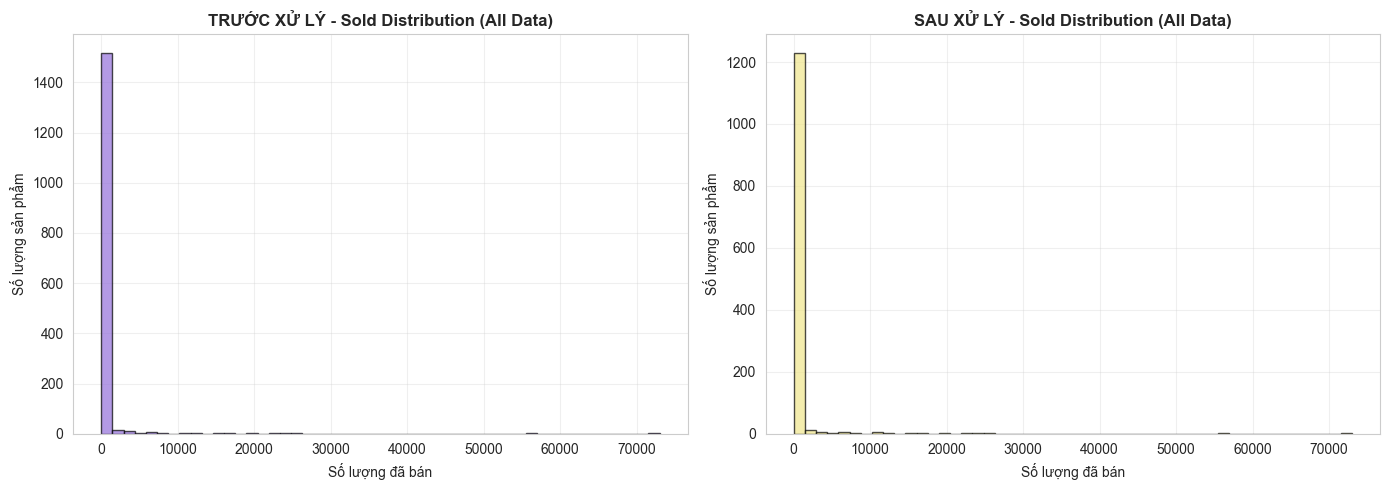

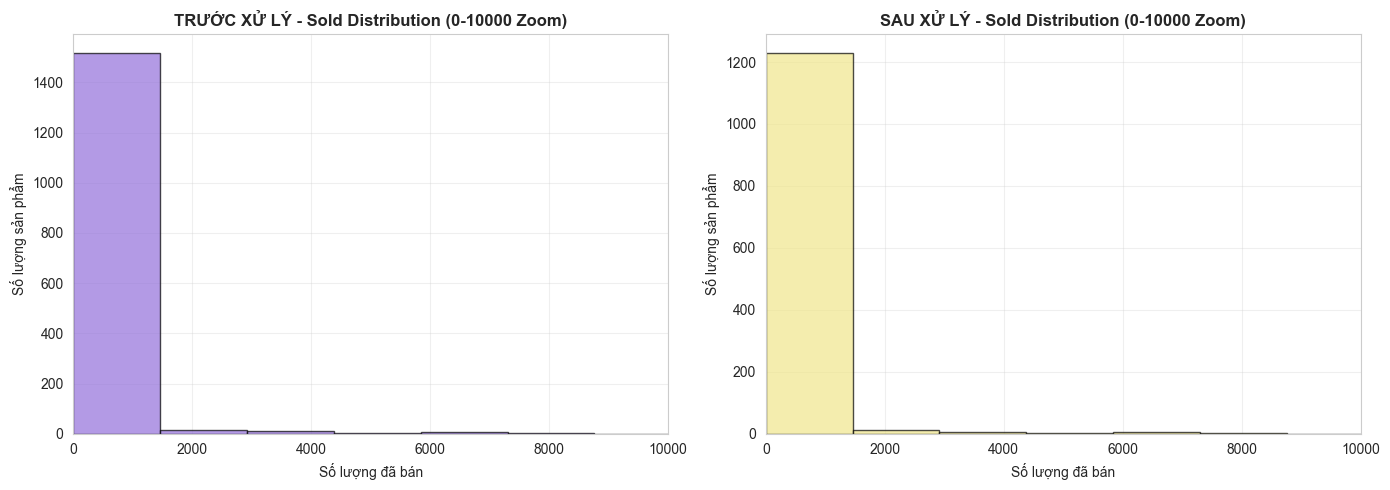


📊 Thống kê SOLD:
TRƯỚC: Mean=398 | Median=19 | Std=2902
SAU:   Mean=453 | Median=20 | Std=3175


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def extract_sold_temp(x):
    if pd.isna(x) or x == '' or x == 'N/A':
        return 0
    match = re.findall(r'\d+', str(x))
    return int(match[-1]) if match else 0

sold_before = df_before['sold'].apply(extract_sold_temp)
sold_after = df_after['sold']

# Hình 1: Toàn bộ dữ liệu
axes[0].hist(sold_before, bins=50, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[0].set_title('TRƯỚC XỬ LÝ - Sold Distribution (All Data)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng đã bán')
axes[0].set_ylabel('Số lượng sản phẩm')
axes[0].grid(alpha=0.3)

axes[1].hist(sold_after, bins=50, color='khaki', alpha=0.7, edgecolor='black')
axes[1].set_title('SAU XỬ LÝ - Sold Distribution (All Data)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng đã bán')
axes[1].set_ylabel('Số lượng sản phẩm')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Hình 2: Zoom vào 0-10000
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

axes2[0].hist(sold_before, bins=50, color='mediumpurple', alpha=0.7, edgecolor='black')
axes2[0].set_xlim(0, 10000)
axes2[0].set_title('TRƯỚC XỬ LÝ - Sold Distribution (0-10000 Zoom)', fontsize=12, fontweight='bold')
axes2[0].set_xlabel('Số lượng đã bán')
axes2[0].set_ylabel('Số lượng sản phẩm')
axes2[0].grid(alpha=0.3)

axes2[1].hist(sold_after, bins=50, color='khaki', alpha=0.7, edgecolor='black')
axes2[1].set_xlim(0, 10000)
axes2[1].set_title('SAU XỬ LÝ - Sold Distribution (0-10000 Zoom)', fontsize=12, fontweight='bold')
axes2[1].set_xlabel('Số lượng đã bán')
axes2[1].set_ylabel('Số lượng sản phẩm')
axes2[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Thống kê SOLD:")
print(f"TRƯỚC: Mean={sold_before.mean():.0f} | Median={sold_before.median():.0f} | Std={sold_before.std():.0f}")
print(f"SAU:   Mean={sold_after.mean():.0f} | Median={sold_after.median():.0f} | Std={sold_after.std():.0f}")

## 9. So Sánh Phân Bố Dữ Liệu - CATEGORY (Danh Mục Sản Phẩm)

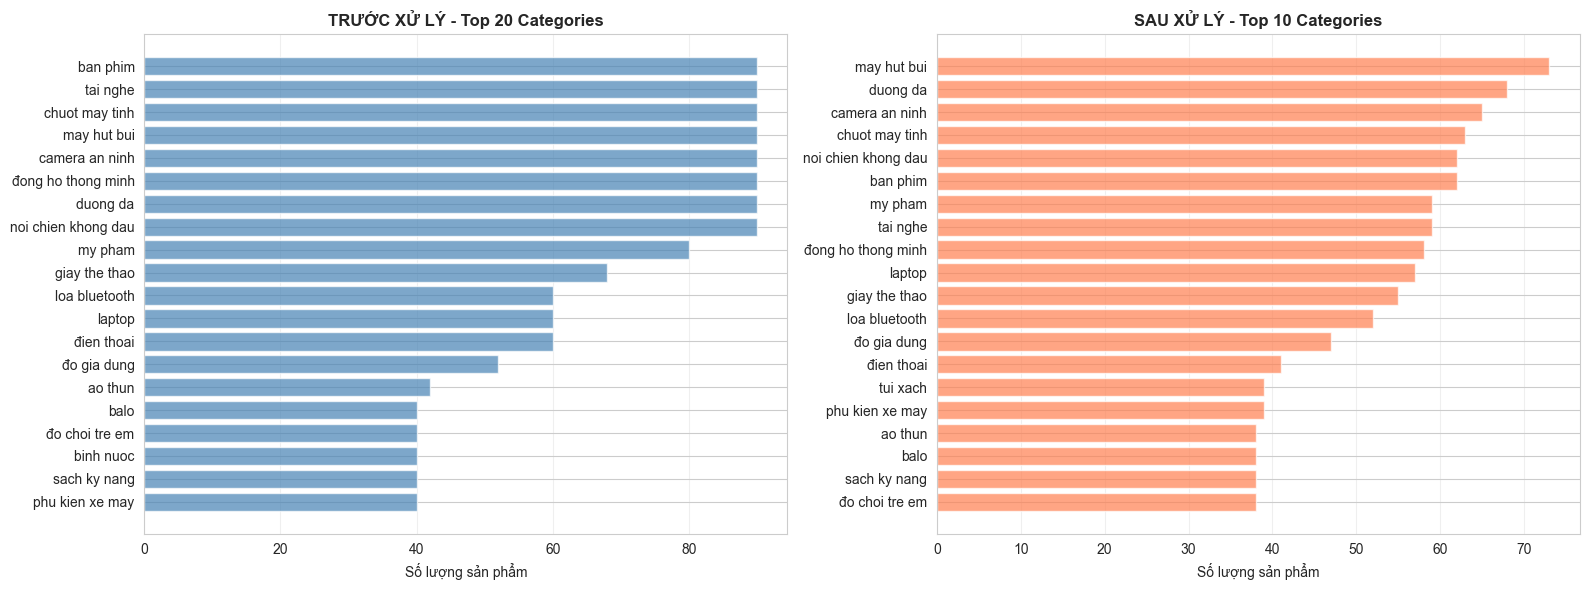


📊 Thống kê CATEGORY:
TRƯỚC XỬ LÝ - Số danh mục unique: 30
Top 5: {'ban phim': 90, 'tai nghe': 90, 'chuot may tinh': 90, 'may hut bui': 90, 'camera an ninh': 90}

SAU XỬ LÝ - Số danh mục unique: 30
Top 5: {'may hut bui': 73, 'duong da': 68, 'camera an ninh': 65, 'chuot may tinh': 63, 'noi chien khong dau': 62}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def remove_vietnamese_diacritics(text):
    if pd.isna(text):
        return text
    text = str(text)
    nfkd_form = unicodedata.normalize('NFKD', text)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

def clean_category_temp(x):
    if pd.isna(x) or x == '':
        return 'other'
    text = str(x).lower()
    text = remove_vietnamese_diacritics(text)
    text = re.sub(r'[^\w\s]+', '', text)
    text = ' '.join(text.split())
    return text if text else 'other'

category_before = df_before['category'].apply(clean_category_temp).value_counts().head(20)
category_after = df_after['category'].value_counts().head(20)

axes[0].barh(range(len(category_before)), category_before.values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(category_before)))
axes[0].set_yticklabels(category_before.index)
axes[0].set_title('TRƯỚC XỬ LÝ - Top 20 Categories', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng sản phẩm')
axes[0].grid(alpha=0.3, axis='x')
axes[0].invert_yaxis()

axes[1].barh(range(len(category_after)), category_after.values, color='coral', alpha=0.7)
axes[1].set_yticks(range(len(category_after)))
axes[1].set_yticklabels(category_after.index)
axes[1].set_title('SAU XỬ LÝ - Top 20 Categories', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng sản phẩm')
axes[1].grid(alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n📊 Thống kê CATEGORY:")
print(f"TRƯỚC XỬ LÝ - Số danh mục unique: {df_before['category'].nunique()}")
print(f"Top 5: {category_before.head(5).to_dict()}")
print(f"\nSAU XỬ LÝ - Số danh mục unique: {df_after['category'].nunique()}")
print(f"Top 5: {category_after.head(5).to_dict()}")

## 10. Tóm Tắt và So Sánh Toàn Bộ

In [45]:
print("=" * 100)
print("📊 TÓM TẮT SO SÁNH DỮ LIỆU TRƯỚC VÀ SAU XỬ LÝ")
print("=" * 100)

summary = pd.DataFrame({
    'Metric': ['Tổng dòng dữ liệu', 'Số cột', 'Dung lượng (KB)'],
    'TRƯỚC XỬ LÝ': [
        len(df_before),
        len(df_before.columns),
        f"{df_before.memory_usage(deep=True).sum() / 1024:.1f}"
    ],
    'SAU XỬ LÝ': [
        len(df_after),
        len(df_after.columns),
        f"{df_after.memory_usage(deep=True).sum() / 1024:.1f}"
    ]
})

print("\n🔹 THÔNG TIN CHUNG:")
print(summary.to_string(index=False))

print("\n🔹 THAY ĐỔI:")
rows_removed = len(df_before) - len(df_after)
print(f"   - Số dòng bị loại bỏ: {rows_removed} ({rows_removed/len(df_before)*100:.1f}%)")
print(f"   - Số dòng còn lại: {len(df_after)}")

print("\n🔹 CÂN NHẮC:")
print("   ✓ Dữ liệu đã được xóa dấu tiếng Việt")
print("   ✓ Các giá trị N/A đã được xử lý (điền median hoặc loại bỏ)")
print("   ✓ Các dòng trùng lặp đã được loại bỏ")
print("   ✓ Các kiểu dữ liệu đã được chuẩn hóa")
print("   ✓ Tất cả các cột đã được làm sạch và chuẩn hóa")

print("\n" + "=" * 100)
print("✅ Trực quan hóa hoàn tất! Xem các biểu đồ ở trên để chi tiết hóa sự thay đổi.")
print("=" * 100)

📊 TÓM TẮT SO SÁNH DỮ LIỆU TRƯỚC VÀ SAU XỬ LÝ

🔹 THÔNG TIN CHUNG:
           Metric TRƯỚC XỬ LÝ SAU XỬ LÝ
Tổng dòng dữ liệu        1565      1272
           Số cột           8         8
  Dung lượng (KB)       899.7     370.5

🔹 THAY ĐỔI:
   - Số dòng bị loại bỏ: 293 (18.7%)
   - Số dòng còn lại: 1272

🔹 CÂN NHẮC:
   ✓ Dữ liệu đã được xóa dấu tiếng Việt
   ✓ Các giá trị N/A đã được xử lý (điền median hoặc loại bỏ)
   ✓ Các dòng trùng lặp đã được loại bỏ
   ✓ Các kiểu dữ liệu đã được chuẩn hóa
   ✓ Tất cả các cột đã được làm sạch và chuẩn hóa

✅ Trực quan hóa hoàn tất! Xem các biểu đồ ở trên để chi tiết hóa sự thay đổi.
